# Goal Achievability Training (Real Historical Labels)

This notebook creates a training table from **real historical snapshots** (no synthetic goals):
- Snapshot month `t` uses only past data as features.
- Label uses observed future behavior over the next `H` months.

Outputs:
1. Regression model: predict `future_cum_net_savings_H`.
2. Classification model: predict `achievable_by_deadline_H`.


## 1) Setup

In [2]:
# Why: set reproducible training configuration.
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report
)

DATA_DIR = Path('.')
SEED = 42
MAX_TX_ROWS = 4_000_000  # increase if your machine supports more
LOOKBACK = 6             # months of past behavior for features
HORIZON = 12             # user deadline horizon in months for labels


# Optional gradient boosting libraries (used only if installed)
HAS_XGBOOST = False
HAS_LIGHTGBM = False
try:
    from xgboost import XGBRegressor, XGBClassifier
    HAS_XGBOOST = True
except Exception:
    pass

try:
    from lightgbm import LGBMRegressor, LGBMClassifier
    HAS_LIGHTGBM = True
except Exception:
    pass

print('Optional libs -> XGBoost:', HAS_XGBOOST, '| LightGBM:', HAS_LIGHTGBM)


Optional libs -> XGBoost: True | LightGBM: True


## 2) Load and Prepare Monthly Data

In [3]:
print('\nSECTION 2: Load and Prepare Monthly Data')

# Why: transform raw transactions into client-month spend and net savings.
def to_money(series):
    return (series.astype(str)
            .str.replace('$', '', regex=False)
            .str.replace(',', '', regex=False)
            .astype(float))

users = pd.read_csv(DATA_DIR / 'users_data.csv')
users['yearly_income'] = to_money(users['yearly_income'])
users['total_debt'] = to_money(users['total_debt'])
users['monthly_income'] = users['yearly_income'] / 12.0

usecols = ['date', 'client_id', 'amount']
chunks, rows = [], 0
for ch in pd.read_csv(DATA_DIR / 'transactions_data.csv', usecols=usecols, chunksize=300_000):
    chunks.append(ch)
    rows += len(ch)
    if rows >= MAX_TX_ROWS:
        break

tx = pd.concat(chunks, ignore_index=True)
tx['amount'] = to_money(tx['amount'])
tx['spend'] = tx['amount'].clip(lower=0.0)
tx['date'] = pd.to_datetime(tx['date'], errors='coerce')
tx['month'] = tx['date'].dt.to_period('M').dt.to_timestamp()

monthly_spend = (tx.groupby(['client_id','month'], as_index=False)['spend']
                   .sum()
                   .sort_values(['client_id','month']))

user_static = users[['id','monthly_income','total_debt','current_age','retirement_age','credit_score','num_credit_cards']]     .rename(columns={'id':'client_id'})

df = monthly_spend.merge(user_static, on='client_id', how='left')
df['net_savings'] = df['monthly_income'] - df['spend']

print('monthly rows:', len(df))
print('clients:', df['client_id'].nunique())
print('months:', df['month'].nunique())



SECTION 2: Load and Prepare Monthly Data
monthly rows: 45824
clients: 1186
months: 40


## 3) Build Snapshot Training Table (No Synthetic Labels)
Label definition uses real observed future months:
- `future_cum_net_savings_H`: sum of actual net savings from `t+1 ... t+H`
- `achievable_by_deadline_H`: whether future savings cover required amount by horizon

Required amount is based on a real obligation proxy from user profile:
- `required_monthly = total_debt / months_to_retirement`
- `required_amount_H = required_monthly * H`


In [4]:
print('\nSECTION 3: Build Snapshot Training Table (Real Historical Labels)')

# Why: create supervised rows from historical windows without inventing outcomes.
rows = []

for client_id, g in df.groupby('client_id'):
    g = g.sort_values('month').reset_index(drop=True)
    n = len(g)
    if n < LOOKBACK + HORIZON + 1:
        continue

    for i in range(LOOKBACK - 1, n - HORIZON - 1):
        hist = g.iloc[i - LOOKBACK + 1:i + 1]
        fut = g.iloc[i + 1:i + 1 + HORIZON]

        # Future label from real observed data
        future_cum = float(fut['net_savings'].sum())

        # Deadline requirement proxy from real user fields
        current_age = float(g.iloc[i]['current_age'])
        retirement_age = float(g.iloc[i]['retirement_age'])
        total_debt = float(g.iloc[i]['total_debt'])

        months_to_ret = max(1.0, (retirement_age - current_age) * 12.0)
        required_monthly = total_debt / months_to_ret
        required_amount_h = required_monthly * HORIZON

        achievable = int(future_cum >= required_amount_h)

        spend_vals = hist['spend'].values
        net_vals = hist['net_savings'].values

        # Feature set (only info available at snapshot time)
        row = {
            'client_id': int(client_id),
            'snapshot_month': pd.Timestamp(g.iloc[i]['month']),
            'lag_spend_1': float(spend_vals[-1]),
            'lag_spend_2': float(spend_vals[-2]),
            'lag_spend_3': float(spend_vals[-3]),
            'roll_spend_mean_3': float(np.mean(spend_vals[-3:])),
            'roll_spend_mean_6': float(np.mean(spend_vals)),
            'roll_spend_std_6': float(np.std(spend_vals, ddof=1)) if len(spend_vals) > 1 else 0.0,
            'roll_net_mean_3': float(np.mean(net_vals[-3:])),
            'roll_net_mean_6': float(np.mean(net_vals)),
            'roll_net_std_6': float(np.std(net_vals, ddof=1)) if len(net_vals) > 1 else 0.0,
            'monthly_income': float(g.iloc[i]['monthly_income']),
            'total_debt': total_debt,
            'credit_score': float(g.iloc[i]['credit_score']),
            'num_credit_cards': float(g.iloc[i]['num_credit_cards']),
            'month_num': int(pd.Timestamp(g.iloc[i]['month']).month),
            'year_num': int(pd.Timestamp(g.iloc[i]['month']).year),
            'required_amount_h': float(required_amount_h),
            'future_cum_net_savings_h': future_cum,
            'achievable_by_deadline_h': achievable,
        }
        rows.append(row)

snap = pd.DataFrame(rows)
print('Snapshot training rows created:', len(snap))
print('Positive class rate (achievable_by_deadline_h = 1):', round(float(snap['achievable_by_deadline_h'].mean()), 4))
print('Preview of snapshot training table:')
snap.head()



SECTION 3: Build Snapshot Training Table (Real Historical Labels)
Snapshot training rows created: 24715
Positive class rate (achievable_by_deadline_h = 1): 0.2803
Preview of snapshot training table:


,client_id,snapshot_month,lag_spend_1,lag_spend_2,lag_spend_3,roll_spend_mean_3,roll_spend_mean_6,roll_spend_std_6,roll_net_mean_3,roll_net_mean_6,roll_net_std_6,monthly_income,total_debt,credit_score,num_credit_cards,month_num,year_num,required_amount_h,future_cum_net_savings_h,achievable_by_deadline_h
0,0,2010-06-01,4269.22,4916.17,5702.19,4962.526667,5343.495000,829.583438,5.223333,-375.745000,829.583438,4967.75,36199.0,763.0,4.0,6,2010,1005.527778,-9813.76,0
1,0,2010-07-01,6466.14,4269.22,4916.17,5217.176667,5582.621667,923.132715,-249.426667,-614.871667,923.132715,4967.75,36199.0,763.0,4.0,7,2010,1005.527778,-8689.77,0
2,0,2010-08-01,5712.58,6466.14,4269.22,5482.646667,5629.586667,921.029000,-514.896667,-661.836667,921.029000,4967.75,36199.0,763.0,4.0,8,2010,1005.527778,-10630.00,0
3,0,2010-09-01,4139.87,5712.58,6466.14,5439.530000,5201.028333,915.294893,-471.780000,-233.278333,915.294893,4967.75,36199.0,763.0,4.0,9,2010,1005.527778,-12208.14,0
4,0,2010-10-01,4334.76,4139.87,5712.58,4729.070000,4973.123333,935.567996,238.680000,-5.373333,935.567996,4967.75,36199.0,763.0,4.0,10,2010,1005.527778,-13081.88,0


## 4) Time-Aware Train/Test Split

In [6]:
print('\nSECTION 4: Time-Aware Train/Test Split')

# Why: evaluate on later snapshots to mimic real future prediction.
feature_cols = [
    'lag_spend_1','lag_spend_2','lag_spend_3',
    'roll_spend_mean_3','roll_spend_mean_6','roll_spend_std_6',
    'roll_net_mean_3','roll_net_mean_6','roll_net_std_6',
    'monthly_income','total_debt','credit_score','num_credit_cards',
    'month_num','year_num','required_amount_h'
]

split_month = snap['snapshot_month'].quantile(0.8)
train_mask = snap['snapshot_month'] <= split_month

train_df = snap[train_mask].copy()
test_df = snap[~train_mask].copy()

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_train_reg = train_df['future_cum_net_savings_h']
y_test_reg = test_df['future_cum_net_savings_h']

y_train_cls = train_df['achievable_by_deadline_h']
y_test_cls = test_df['achievable_by_deadline_h']

print('Time split cutoff month (80th percentile):', split_month)
print('Train rows:', len(train_df), '| Test rows:', len(test_df))
print('Feature count:', len(feature_cols))



SECTION 4: Time-Aware Train/Test Split
Time split cutoff month (80th percentile): 2011-11-01 00:00:00
Train rows: 20126 | Test rows: 4589
Feature count: 16


## 5) Regression Baselines + ML Comparison (Future Cumulative Savings)


In [7]:
print('SECTION 5: Regression Baselines + ML Comparison')

# Goal of this section:
# 1) Establish practical regression baselines FIRST.
# 2) Compare ML models against those baselines on the same test split.
# 3) Select the best ML model for downstream inference (best_reg_model).

# -------------------------
# Baseline models (regression)
# -------------------------
# Baseline 1: Rolling 3-month net-savings average projected across HORIZON.
baseline_roll3 = X_test['roll_net_mean_3'] * HORIZON

# Baseline 2: Last-month net-savings projected across HORIZON.
baseline_last_month = (X_test['monthly_income'] - X_test['lag_spend_1']) * HORIZON

# Baseline 3: Global mean of training target.
baseline_global_mean = np.full(len(y_test_reg), y_train_reg.mean())

reg_rows = []

for name, pred in [
    ('Baseline_Rolling3xH', baseline_roll3),
    ('Baseline_LastMonthxH', baseline_last_month),
    ('Baseline_GlobalMean', baseline_global_mean),
]:
    reg_rows.append({
        'model': name,
        'type': 'baseline',
        'MAE': mean_absolute_error(y_test_reg, pred),
        'RMSE': mean_squared_error(y_test_reg, pred, squared=False),
        'R2': r2_score(y_test_reg, pred)
    })

# -------------------------
# ML models (regression)
# -------------------------
reg_models = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(
        n_estimators=180,
        max_depth=12,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features='sqrt',
        random_state=SEED,
        n_jobs=1
    )
}

# Optional ML challengers: included only if libs are available.
if 'HAS_XGBOOST' in globals() and HAS_XGBOOST:
    reg_models['XGBoostRegressor'] = XGBRegressor(
        n_estimators=250,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=SEED,
        n_jobs=1
    )
if 'HAS_LIGHTGBM' in globals() and HAS_LIGHTGBM:
    reg_models['LightGBMRegressor'] = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED
    )

fitted_reg = {}
for name, model in reg_models.items():
    model.fit(X_train, y_train_reg)
    pred = model.predict(X_test)

    reg_rows.append({
        'model': name,
        'type': 'ml',
        'MAE': mean_absolute_error(y_test_reg, pred),
        'RMSE': mean_squared_error(y_test_reg, pred, squared=False),
        'R2': r2_score(y_test_reg, pred)
    })
    fitted_reg[name] = model

reg_results = pd.DataFrame(reg_rows).sort_values(['RMSE','MAE'])
print('Regression comparison table (baselines + ML + optional XGBoost/LightGBM if installed):')
display(reg_results)

best_baseline_reg = reg_results[reg_results['type'] == 'baseline'].iloc[0]
best_ml_reg = reg_results[reg_results['type'] == 'ml'].iloc[0]

print('Best regression baseline:', best_baseline_reg['model'])
print('Best regression ML model:', best_ml_reg['model'])
print('RMSE improvement of best ML vs best baseline (%):',
      round((best_baseline_reg['RMSE'] - best_ml_reg['RMSE']) / best_baseline_reg['RMSE'] * 100, 2))

# Select best ML model object for downstream inference.
best_reg_name = best_ml_reg['model']
best_reg_model = fitted_reg[best_reg_name]
print('Selected best regression model for deployment (best_reg_model):', best_reg_name)


SECTION 5: Regression Baselines + ML Comparison
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000776 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3311
[LightGBM] [Info] Number of data points in the train set: 20126, number of used features: 16
[LightGBM] [Info] Start training from score -9877.451171
Regression comparison table (baselines + ML + optional XGBoost/LightGBM if installed):


,model,type,MAE,RMSE,R2
6,LightGBMRegressor,ml,3867.790952,5199.854546,0.970908
5,XGBoostRegressor,ml,3901.814746,5264.394290,0.970181
4,RandomForestRegressor,ml,3865.530608,5269.285271,0.970126
3,LinearRegression,ml,4075.628744,5409.983496,0.968509
0,Baseline_Rolling3xH,baseline,5388.961207,7336.954052,0.942081
1,Baseline_LastMonthxH,baseline,8632.631366,11999.644453,0.845072
2,Baseline_GlobalMean,baseline,21021.629792,30486.704894,-0.000030


Best regression baseline: Baseline_Rolling3xH
Best regression ML model: LightGBMRegressor
RMSE improvement of best ML vs best baseline (%): 29.13
Selected best regression model for deployment (best_reg_model): LightGBMRegressor


## 6) Classification Baselines + ML Comparison (Achievable By Deadline)


In [8]:
print('SECTION 6: Classification Baselines + ML Comparison')

# Goal of this section:
# 1) Establish classification baselines FIRST (majority + rule-based).
# 2) Compare ML classifiers against those baselines on the same test split.
# 3) Select the best ML classifier object as best_cls_model.

# -------------------------
# Baseline models (classification)
# -------------------------
# Baseline 1: Majority class baseline.
majority_class = int(y_train_cls.mode().iloc[0])
majority_pred = np.full(len(y_test_cls), majority_class)
# Constant probability baseline using positive rate in train set.
majority_proba = np.full(len(y_test_cls), float(y_train_cls.mean()))

# Baseline 2: Simple rule-based threshold.
# Rule: projected savings by rolling trend >= required amount => achievable.
rule_signal = (X_test['roll_net_mean_3'] * HORIZON) - X_test['required_amount_h']
rule_pred = (rule_signal >= 0).astype(int)
# Convert rule signal to smooth probability for AUC metrics.
rule_scale = X_test['required_amount_h'].abs().replace(0, 1.0)
rule_proba = 1.0 / (1.0 + np.exp(-(rule_signal / rule_scale)))

cls_rows = []
for name, pred, proba in [
    ('Baseline_MajorityClass', majority_pred, majority_proba),
    ('Baseline_RuleThreshold', rule_pred, rule_proba),
]:
    cls_rows.append({
        'model': name,
        'type': 'baseline',
        'Accuracy': accuracy_score(y_test_cls, pred),
        'Precision': precision_score(y_test_cls, pred, zero_division=0),
        'Recall': recall_score(y_test_cls, pred, zero_division=0),
        'F1': f1_score(y_test_cls, pred, zero_division=0),
        'AUC': roc_auc_score(y_test_cls, proba),
        'PR_AUC': average_precision_score(y_test_cls, proba)
    })

# -------------------------
# ML models (classification)
# -------------------------
cls_models = {
    'LogisticRegression': LogisticRegression(max_iter=400, random_state=SEED),
    'RandomForestClassifier': RandomForestClassifier(
        n_estimators=180,
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=8,
        max_features='sqrt',
        random_state=SEED,
        n_jobs=1,
        class_weight='balanced_subsample'
    )
}

# Optional ML challengers: included only if libs are available.
if 'HAS_XGBOOST' in globals() and HAS_XGBOOST:
    cls_models['XGBoostClassifier'] = XGBClassifier(
        n_estimators=250,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=SEED,
        n_jobs=1
    )
if 'HAS_LIGHTGBM' in globals() and HAS_LIGHTGBM:
    cls_models['LightGBMClassifier'] = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED
    )

fitted_cls = {}
for name, model in cls_models.items():
    model.fit(X_train, y_train_cls)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:,1]

    cls_rows.append({
        'model': name,
        'type': 'ml',
        'Accuracy': accuracy_score(y_test_cls, pred),
        'Precision': precision_score(y_test_cls, pred, zero_division=0),
        'Recall': recall_score(y_test_cls, pred, zero_division=0),
        'F1': f1_score(y_test_cls, pred, zero_division=0),
        'AUC': roc_auc_score(y_test_cls, proba),
        'PR_AUC': average_precision_score(y_test_cls, proba)
    })
    fitted_cls[name] = model

cls_results = pd.DataFrame(cls_rows).sort_values(['F1','AUC'], ascending=False)
print('Classification comparison table (baselines + ML + optional XGBoost/LightGBM if installed):')
display(cls_results)

best_baseline_cls = cls_results[cls_results['type'] == 'baseline'].iloc[0]
best_ml_cls = cls_results[cls_results['type'] == 'ml'].iloc[0]

print('Best classification baseline:', best_baseline_cls['model'])
print('Best classification ML model:', best_ml_cls['model'])
print('F1 lift of best ML vs best baseline (%):',
      round((best_ml_cls['F1'] - best_baseline_cls['F1']) / max(best_baseline_cls['F1'], 1e-9) * 100, 2))

# Select best ML classifier object for downstream diagnostics and inference.
best_cls_name = best_ml_cls['model']
best_cls_model = fitted_cls[best_cls_name]
print('Selected best classification model (stored in best_cls_model):', best_cls_name)


SECTION 6: Classification Baselines + ML Comparison
[LightGBM] [Info] Number of positive: 5615, number of negative: 14511
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000548 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3311
[LightGBM] [Info] Number of data points in the train set: 20126, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.278992 -> initscore=-0.949465
[LightGBM] [Info] Start training from score -0.949465
Classification comparison table (baselines + ML + optional XGBoost/LightGBM if installed):


,model,type,Accuracy,Precision,Recall,F1,AUC,PR_AUC
5,LightGBMClassifier,ml,0.946394,0.911334,0.900228,0.905747,0.988483,0.970736
4,XGBoostClassifier,ml,0.941817,0.900459,0.895659,0.898053,0.986864,0.966059
3,RandomForestClassifier,ml,0.933537,0.833333,0.959634,0.892035,0.984093,0.958661
2,LogisticRegression,ml,0.926564,0.875385,0.866717,0.871029,0.981091,0.951648
1,Baseline_RuleThreshold,baseline,0.911745,0.839312,0.855293,0.847227,0.934960,0.858628
0,Baseline_MajorityClass,baseline,0.713881,0.000000,0.000000,0.000000,0.500000,0.286119


Best classification baseline: Baseline_RuleThreshold
Best classification ML model: LightGBMClassifier
F1 lift of best ML vs best baseline (%): 6.91
Selected best classification model (stored in best_cls_model): LightGBMClassifier


## 7) Joint Inference Pattern for Goal Page
At runtime with user-provided deadline:
1. Build current snapshot features.
2. Regression predicts expected cumulative savings by horizon.
3. Classification predicts probability of achievability by deadline.
4. Combine both for final UX message.


In [9]:
print('\nSECTION 10: Joint Inference Output Example')

# Why: show a concrete output contract for the Goal page.

def goal_page_output(features_row):
    # features_row: one-row DataFrame with feature_cols
    pred_cum_savings = float(best_reg_model.predict(features_row[feature_cols])[0])
    proba_achievable = float(best_cls_model.predict_proba(features_row[feature_cols])[:,1][0])
    cls_flag = int(proba_achievable >= 0.5)

    return {
        'predicted_cumulative_savings_by_deadline': pred_cum_savings,
        'probability_achievable_by_deadline': proba_achievable,
        'achievable_by_deadline': bool(cls_flag)
    }

# Example using one test row
example_row = test_df.head(1).copy()
print('Example goal-page output dictionary for one test row:')
print(goal_page_output(example_row))



SECTION 10: Joint Inference Output Example
Example goal-page output dictionary for one test row:
{'predicted_cumulative_savings_by_deadline': -14961.727667656913, 'probability_achievable_by_deadline': 0.009258098138434328, 'achievable_by_deadline': False}


## 7) Class Imbalance Diagnostics


In [10]:
# Detailed purpose of this diagnostics block:
# - Confirm class balance in full/train/test splits.
# - Benchmark against a naive majority-class predictor.
# - Evaluate the EXACT selected classifier object: `best_cls_model`.
#   `best_cls_model` is chosen in Section 6 from candidate models
#   (LogisticRegression vs RandomForestClassifier).
# - Report ROC-AUC, PR-AUC, confusion matrix, and per-class metrics
#   so we can detect imbalance side effects and false positive/negative patterns.

print('\nSECTION 7: Class Imbalance Diagnostics')

# Works with either notebook variable names.
if 'y_train_cls' in globals() and 'y_test_cls' in globals():
    _y_train_cls, _y_test_cls = y_train_cls, y_test_cls
elif 'test_df' in globals() and 'achievable_by_deadline_h' in test_df.columns and 'train_df' in globals():
    _y_train_cls = train_df['achievable_by_deadline_h']
    _y_test_cls = test_df['achievable_by_deadline_h']
else:
    raise RuntimeError('Classification labels not found. Run classification training cells first.')

if 'best_cls_model' not in globals():
    raise RuntimeError('best_cls_model not found. Run classification model cell first.')

print('Selected classifier object in use: best_cls_model')
if 'best_cls_name' in globals():
    print('Selected classifier model name:', best_cls_name)

if 'X_test' not in globals() or 'X_train' not in globals():
    raise RuntimeError('X_train/X_test not found. Run split/training cells first.')

def _dist(s, name):
    d = pd.DataFrame({'count': s.value_counts().sort_index(),
                      'pct': (s.value_counts(normalize=True).sort_index()*100).round(2)})
    print(name)
    display(d)

if 'snap' in globals() and 'achievable_by_deadline_h' in snap.columns:
    _dist(snap['achievable_by_deadline_h'], 'Full class distribution')
_dist(_y_train_cls, 'Train class distribution')
_dist(_y_test_cls, 'Test class distribution')

maj = int(_y_train_cls.mode().iloc[0])
maj_pred = np.full(len(_y_test_cls), maj)
# Majority baseline = predict only dominant class from train split.
# If model barely beats this, classifier is not useful under imbalance.
print('Majority-class baseline on test set:', {
    'Accuracy': accuracy_score(_y_test_cls, maj_pred),
    'Precision': precision_score(_y_test_cls, maj_pred, zero_division=0),
    'Recall': recall_score(_y_test_cls, maj_pred, zero_division=0),
    'F1': f1_score(_y_test_cls, maj_pred, zero_division=0),
})

t_pred = best_cls_model.predict(X_test)
t_prob = best_cls_model.predict_proba(X_test)[:,1]
# ROC-AUC: ranking quality overall.
# PR-AUC: more informative when positive class is less frequent.
print('best_cls_model ROC-AUC (test):', roc_auc_score(_y_test_cls, t_prob))
print('best_cls_model PR-AUC (test):', average_precision_score(_y_test_cls, t_prob))

print('Confusion matrix (rows=actual, cols=predicted):')
display(pd.DataFrame(confusion_matrix(_y_test_cls, t_pred),
                     index=['Actual_0','Actual_1'], columns=['Pred_0','Pred_1']))
print('Classification report (test set):')
print(classification_report(_y_test_cls, t_pred, digits=4))



SECTION 7: Class Imbalance Diagnostics
Selected classifier object in use: best_cls_model
Selected classifier model name: LightGBMClassifier
Full class distribution


,count,pct
achievable_by_deadline_h,,
0,17787,71.97
1,6928,28.03


Train class distribution


,count,pct
achievable_by_deadline_h,,
0,14511,72.1
1,5615,27.9


Test class distribution


,count,pct
achievable_by_deadline_h,,
0,3276,71.39
1,1313,28.61


Majority-class baseline on test set: {'Accuracy': 0.7138810198300283, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
best_cls_model ROC-AUC (test): 0.9884832523827192
best_cls_model PR-AUC (test): 0.970736139544444
Confusion matrix (rows=actual, cols=predicted):


,Pred_0,Pred_1
Actual_0,3161,115
Actual_1,131,1182


Classification report (test set):
              precision    recall  f1-score   support

           0     0.9602    0.9649    0.9625      3276
           1     0.9113    0.9002    0.9057      1313

    accuracy                         0.9464      4589
   macro avg     0.9358    0.9326    0.9341      4589
weighted avg     0.9462    0.9464    0.9463      4589



## 8) Overfitting Checks (Train vs Test)


In [11]:
# Overfitting check logic:
# - Compute metrics on TRAIN and TEST using the selected best models.
# - If train is much better than test, the model may be memorizing patterns.
# - Small gap with good test performance implies healthier generalization.
# This section checks both heads:
#   1) best_reg_model (regression)
#   2) best_cls_model (classification)
print('SECTION 8: Overfitting Checks (Train vs Test)')

if 'X_train' not in globals() or 'X_test' not in globals():
    raise RuntimeError('X_train/X_test not found. Run split cell first.')

# Regression checks
if 'best_reg_model' in globals() and ('y_train_reg' in globals()) and ('y_test_reg' in globals()):
    rp_tr = best_reg_model.predict(X_train)
    rp_te = best_reg_model.predict(X_test)
    print('Regression train vs test performance (overfitting check):')
    display(pd.DataFrame([
        {'split':'train','MAE':mean_absolute_error(y_train_reg, rp_tr),'RMSE':mean_squared_error(y_train_reg, rp_tr, squared=False),'R2':r2_score(y_train_reg, rp_tr)},
        {'split':'test','MAE':mean_absolute_error(y_test_reg, rp_te),'RMSE':mean_squared_error(y_test_reg, rp_te, squared=False),'R2':r2_score(y_test_reg, rp_te)}
    ]))
elif 'best_model' in globals() and ('y_train' in globals()) and ('y_test' in globals()):
    rp_tr = best_model.predict(X_train)
    rp_te = best_model.predict(X_test)
    print('Regression train vs test performance (overfitting check):')
    display(pd.DataFrame([
        {'split':'train','MAE':mean_absolute_error(y_train, rp_tr),'RMSE':mean_squared_error(y_train, rp_tr, squared=False),'R2':r2_score(y_train, rp_tr)},
        {'split':'test','MAE':mean_absolute_error(y_test, rp_te),'RMSE':mean_squared_error(y_test, rp_te, squared=False),'R2':r2_score(y_test, rp_te)}
    ]))
else:
    print('Regression model/targets not found in this notebook state.')

# Classification checks
if 'best_cls_model' in globals() and ('_y_train_cls' in globals()) and ('_y_test_cls' in globals()):
    cpr_tr = best_cls_model.predict_proba(X_train)[:,1]
    cpr_te = best_cls_model.predict_proba(X_test)[:,1]

    # Use tuned threshold when available; fallback to 0.50.
    th = FINAL_THRESHOLD if 'FINAL_THRESHOLD' in globals() else 0.50
    cp_tr = (cpr_tr >= th).astype(int)
    cp_te = (cpr_te >= th).astype(int)

    print(f'Classification train vs test performance (overfitting check) at threshold={th:.2f}:')
    display(pd.DataFrame([
        {'split':'train','Accuracy':accuracy_score(_y_train_cls, cp_tr),'Precision':precision_score(_y_train_cls, cp_tr, zero_division=0),'Recall':recall_score(_y_train_cls, cp_tr, zero_division=0),'F1':f1_score(_y_train_cls, cp_tr, zero_division=0),'AUC':roc_auc_score(_y_train_cls, cpr_tr)},
        {'split':'test','Accuracy':accuracy_score(_y_test_cls, cp_te),'Precision':precision_score(_y_test_cls, cp_te, zero_division=0),'Recall':recall_score(_y_test_cls, cp_te, zero_division=0),'F1':f1_score(_y_test_cls, cp_te, zero_division=0),'AUC':roc_auc_score(_y_test_cls, cpr_te)}
    ]))
else:
    print('Classification model/targets not found in this notebook state.')


SECTION 8: Overfitting Checks (Train vs Test)
Regression train vs test performance (overfitting check):


,split,MAE,RMSE,R2
0,train,3189.240573,4184.485155,0.981357
1,test,3867.790952,5199.854546,0.970908


Classification train vs test performance (overfitting check) at threshold=0.50:


,split,Accuracy,Precision,Recall,F1,AUC
0,train,0.990013,0.980817,0.983437,0.982125,0.999476
1,test,0.946394,0.911334,0.900228,0.905747,0.988483


## 9) Threshold Tuning (Precision vs Recall)



SECTION 9: Threshold Tuning Diagnostics
Top threshold candidates by F1 on test set:


,threshold,Precision,Recall,F1
8,0.45,0.904583,0.916984,0.910741
7,0.40,0.898368,0.922315,0.910184
6,0.35,0.883537,0.936024,0.909024
5,0.30,0.874471,0.944402,0.908092
9,0.50,0.911334,0.900228,0.905747
4,0.25,0.862164,0.952780,0.905210
10,0.55,0.918770,0.887281,0.902751
3,0.20,0.846359,0.964966,0.901779
11,0.60,0.923756,0.876618,0.899570
2,0.15,0.830629,0.974867,0.896987


Best threshold by F1: 0.45


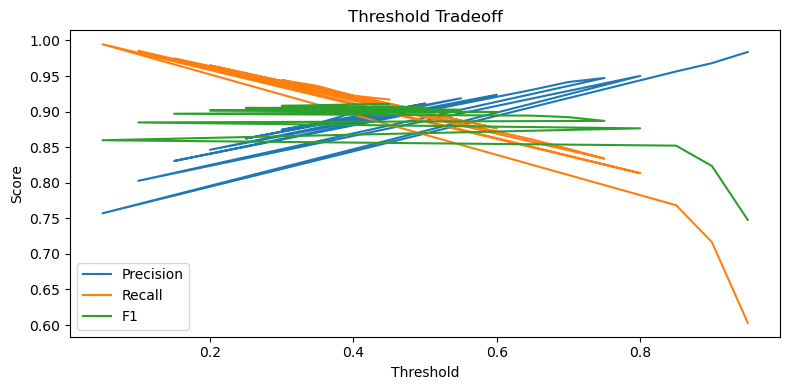

FINAL_THRESHOLD initialized from F1-optimal threshold: 0.45


In [12]:
# Threshold tuning rationale:
# - best_cls_model outputs probabilities. A fixed 0.50 threshold is arbitrary.
# - We sweep thresholds and compute Precision/Recall/F1 trade-offs.
# - Product decision:
#     higher threshold -> fewer false YES (higher precision, lower recall)
#     lower threshold  -> fewer missed YES (higher recall, lower precision)

print('\nSECTION 9: Threshold Tuning Diagnostics')

if 'best_cls_model' not in globals() or 'X_test' not in globals() or '_y_test_cls' not in globals():
    raise RuntimeError('Need best_cls_model, X_test, and class labels. Run section 7 first.')

proba = best_cls_model.predict_proba(X_test)[:,1]
ths = np.arange(0.05, 0.96, 0.05)
rows=[]
for t in ths:
    p = (proba >= t).astype(int)
    rows.append({'threshold':round(float(t),2),
                 'Precision':precision_score(_y_test_cls,p,zero_division=0),
                 'Recall':recall_score(_y_test_cls,p,zero_division=0),
                 'F1':f1_score(_y_test_cls,p,zero_division=0)})

tdf=pd.DataFrame(rows).sort_values('F1', ascending=False)
print('Top threshold candidates by F1 on test set:')
display(tdf.head(10))
BEST_THRESHOLD_F1 = float(tdf.iloc[0]['threshold'])
print('Best threshold by F1:', BEST_THRESHOLD_F1)

plt.figure(figsize=(8,4))
plt.plot(tdf['threshold'], tdf['Precision'], label='Precision')
plt.plot(tdf['threshold'], tdf['Recall'], label='Recall')
plt.plot(tdf['threshold'], tdf['F1'], label='F1')
plt.legend(); plt.xlabel('Threshold'); plt.ylabel('Score'); plt.title('Threshold Tradeoff'); plt.tight_layout(); plt.show()

# Expose default final threshold unless overridden in final policy section.
if 'FINAL_THRESHOLD' not in globals():
    FINAL_THRESHOLD = BEST_THRESHOLD_F1
    print('FINAL_THRESHOLD initialized from F1-optimal threshold:', FINAL_THRESHOLD)


## 10) Joint Inference Pattern for Goal Page


## 11) Time-Series Cross-Validation (Both Models)


In [13]:
# This block runs rolling time-series CV for more robust generalization estimates.

print('\nSECTION 11: Time-Series Cross-Validation')

# Cross-validation design:
# - TimeSeriesSplit preserves chronological order (no future leakage).
# - Each fold trains on earlier data and validates on a later window.
# - We compute mean + std across folds to measure both performance and stability.
# - Lower std means model behavior is more stable over time.
if 'snap' not in globals() or 'feature_cols' not in globals():
    raise RuntimeError('Run snapshot and feature-engineering cells first.')

from sklearn.model_selection import TimeSeriesSplit

cv_df = snap.sort_values('snapshot_month').reset_index(drop=True)
X_cv = cv_df[feature_cols]
y_reg_cv = cv_df['future_cum_net_savings_h']
y_cls_cv = cv_df['achievable_by_deadline_h']

tscv = TimeSeriesSplit(n_splits=5)

reg_models_cv = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=180, max_depth=12, min_samples_split=20, min_samples_leaf=10, max_features='sqrt', random_state=SEED, n_jobs=1)
}
if 'HAS_XGBOOST' in globals() and HAS_XGBOOST:
    reg_models_cv['XGBoostRegressor'] = XGBRegressor(n_estimators=250, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, objective='reg:squarederror', random_state=SEED, n_jobs=1)
if 'HAS_LIGHTGBM' in globals() and HAS_LIGHTGBM:
    reg_models_cv['LightGBMRegressor'] = LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31, subsample=0.8, colsample_bytree=0.8, random_state=SEED)

cls_models_cv = {
    'LogisticRegression': LogisticRegression(max_iter=400, random_state=SEED),
    'RandomForestClassifier': RandomForestClassifier(n_estimators=180, max_depth=10, min_samples_split=20, min_samples_leaf=8, max_features='sqrt', random_state=SEED, n_jobs=1, class_weight='balanced_subsample')
}
if 'HAS_XGBOOST' in globals() and HAS_XGBOOST:
    cls_models_cv['XGBoostClassifier'] = XGBClassifier(n_estimators=250, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=SEED, n_jobs=1)
if 'HAS_LIGHTGBM' in globals() and HAS_LIGHTGBM:
    cls_models_cv['LightGBMClassifier'] = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, subsample=0.8, colsample_bytree=0.8, random_state=SEED)

reg_rows = []
for name, model in reg_models_cv.items():
    fold = []
    for tr, te in tscv.split(X_cv):
        X_tr, X_te = X_cv.iloc[tr], X_cv.iloc[te]
        y_tr, y_te = y_reg_cv.iloc[tr], y_reg_cv.iloc[te]
        model.fit(X_tr, y_tr)
        p = model.predict(X_te)
        fold.append((mean_absolute_error(y_te, p), mean_squared_error(y_te, p, squared=False), r2_score(y_te, p)))
    f = np.array(fold)
    reg_rows.append({'model':name, 'MAE_mean':f[:,0].mean(), 'MAE_std':f[:,0].std(), 'RMSE_mean':f[:,1].mean(), 'RMSE_std':f[:,1].std(), 'R2_mean':f[:,2].mean(), 'R2_std':f[:,2].std()})

print('Regression time-series CV summary (includes optional XGBoost/LightGBM if installed):')
display(pd.DataFrame(reg_rows).sort_values(['RMSE_mean','MAE_mean']))

cls_rows = []
for name, model in cls_models_cv.items():
    fold = []
    for tr, te in tscv.split(X_cv):
        X_tr, X_te = X_cv.iloc[tr], X_cv.iloc[te]
        y_tr, y_te = y_cls_cv.iloc[tr], y_cls_cv.iloc[te]
        model.fit(X_tr, y_tr)
        p = model.predict(X_te)
        pr = model.predict_proba(X_te)[:,1]
        fold.append((
            accuracy_score(y_te, p),
            precision_score(y_te, p, zero_division=0),
            recall_score(y_te, p, zero_division=0),
            f1_score(y_te, p, zero_division=0),
            roc_auc_score(y_te, pr),
            average_precision_score(y_te, pr)
        ))
    f = np.array(fold)
    cls_rows.append({'model':name, 'Accuracy_mean':f[:,0].mean(), 'Precision_mean':f[:,1].mean(), 'Recall_mean':f[:,2].mean(), 'F1_mean':f[:,3].mean(), 'AUC_mean':f[:,4].mean(), 'PR_AUC_mean':f[:,5].mean(), 'F1_std':f[:,3].std(), 'AUC_std':f[:,4].std()})

print('Classification time-series CV summary (includes optional XGBoost/LightGBM if installed):')
display(pd.DataFrame(cls_rows).sort_values(['F1_mean','AUC_mean'], ascending=False))



SECTION 11: Time-Series Cross-Validation
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000342 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3301
[LightGBM] [Info] Number of data points in the train set: 4120, number of used features: 15
[LightGBM] [Info] Start training from score -9819.321566
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000510 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3308
[LightGBM] [Info] Number of data points in the train set: 8239, number of used features: 16
[LightGBM] [Info] Start training from score -9947.739336
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000858 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3311
[LightGBM] [Info] Number of data points in the train set: 12358, number 

,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
2,XGBoostRegressor,4018.567835,57.101342,5498.091500,159.772793,0.967651,0.001735
3,LightGBMRegressor,4058.056278,75.211270,5596.155159,222.621487,0.966470,0.002430
0,LinearRegression,4367.685602,211.957258,5926.921154,344.810694,0.962343,0.003979
1,RandomForestRegressor,4203.733685,258.464878,6027.800903,677.493335,0.960778,0.008475


[LightGBM] [Info] Number of positive: 1137, number of negative: 2983
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000458 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3301
[LightGBM] [Info] Number of data points in the train set: 4120, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.275971 -> initscore=-0.964536
[LightGBM] [Info] Start training from score -0.964536
[LightGBM] [Info] Number of positive: 2274, number of negative: 5965
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000694 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3308
[LightGBM] [Info] Number of data points in the train set: 8239, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.276004 -> initscore=-0.964369
[LightGBM] [Info] Start training from score -0.964369
[LightGBM] [Info] 

,model,Accuracy_mean,Precision_mean,Recall_mean,F1_mean,AUC_mean,PR_AUC_mean,F1_std,AUC_std
3,LightGBMClassifier,0.943676,0.898084,0.902197,0.900055,0.984721,0.958782,0.009450,0.002500
2,XGBoostClassifier,0.941151,0.893999,0.897221,0.895556,0.983761,0.956320,0.010264,0.002308
1,RandomForestClassifier,0.924496,0.822573,0.932962,0.874090,0.979272,0.945516,0.007495,0.003208
0,LogisticRegression,0.925127,0.861971,0.874359,0.867877,0.977117,0.939792,0.005600,0.002542


## 12) Final Production Selection (Models + Threshold)
This section finalizes:
1. Primary models (prefer LightGBM when available).
2. Threshold policy (`balanced`, `high_precision`, `high_recall`).
3. Final artifacts to use in Goal-page inference.


In [14]:

print('SECTION 12: Final Production Selection')

# --------- Model lock-in policy ---------
# Prefer LightGBM as primary if it exists in fitted dicts, else fallback to best-ranked ML model.
preferred_reg = 'LightGBMRegressor'
preferred_cls = 'LightGBMClassifier'

if 'fitted_reg' not in globals() or 'fitted_cls' not in globals():
    raise RuntimeError('Run Sections 5 and 6 first so fitted model dictionaries exist.')

FINAL_REG_MODEL_NAME = preferred_reg if preferred_reg in fitted_reg else best_reg_name
FINAL_CLS_MODEL_NAME = preferred_cls if preferred_cls in fitted_cls else best_cls_name

best_reg_model = fitted_reg[FINAL_REG_MODEL_NAME]
best_cls_model = fitted_cls[FINAL_CLS_MODEL_NAME]

print('Final regression model:', FINAL_REG_MODEL_NAME)
print('Final classification model:', FINAL_CLS_MODEL_NAME)

# --------- Threshold policy ---------
# Choose one policy for production:
# - balanced: maximize F1
# - high_precision: maximize precision with recall >= 0.70
# - high_recall: maximize recall with precision >= 0.70
THRESHOLD_POLICY = 'balanced'  # change as needed

if 'X_test' not in globals() or '_y_test_cls' not in globals():
    raise RuntimeError('Run diagnostics Section 7 first to set classification labels.')

proba_test = best_cls_model.predict_proba(X_test)[:,1]
ths = np.arange(0.05, 0.96, 0.01)
rows = []
for t in ths:
    pred = (proba_test >= t).astype(int)
    rows.append({
        'threshold': float(t),
        'Precision': precision_score(_y_test_cls, pred, zero_division=0),
        'Recall': recall_score(_y_test_cls, pred, zero_division=0),
        'F1': f1_score(_y_test_cls, pred, zero_division=0)
    })
policy_df = pd.DataFrame(rows)

if THRESHOLD_POLICY == 'balanced':
    FINAL_THRESHOLD = float(policy_df.sort_values('F1', ascending=False).iloc[0]['threshold'])
elif THRESHOLD_POLICY == 'high_precision':
    cand = policy_df[policy_df['Recall'] >= 0.70]
    FINAL_THRESHOLD = float((cand if not cand.empty else policy_df).sort_values('Precision', ascending=False).iloc[0]['threshold'])
elif THRESHOLD_POLICY == 'high_recall':
    cand = policy_df[policy_df['Precision'] >= 0.70]
    FINAL_THRESHOLD = float((cand if not cand.empty else policy_df).sort_values('Recall', ascending=False).iloc[0]['threshold'])
else:
    raise ValueError('Unknown THRESHOLD_POLICY')

print('Threshold policy:', THRESHOLD_POLICY)
print('Selected FINAL_THRESHOLD:', FINAL_THRESHOLD)

# Show final metrics at selected threshold
pred_final = (proba_test >= FINAL_THRESHOLD).astype(int)
print('Final classification metrics at selected threshold:')
print({
    'Accuracy': accuracy_score(_y_test_cls, pred_final),
    'Precision': precision_score(_y_test_cls, pred_final, zero_division=0),
    'Recall': recall_score(_y_test_cls, pred_final, zero_division=0),
    'F1': f1_score(_y_test_cls, pred_final, zero_division=0),
    'AUC': roc_auc_score(_y_test_cls, proba_test),
    'PR_AUC': average_precision_score(_y_test_cls, proba_test)
})


SECTION 12: Final Production Selection
Final regression model: LightGBMRegressor
Final classification model: LightGBMClassifier
Threshold policy: balanced
Selected FINAL_THRESHOLD: 0.4100000000000001
Final classification metrics at selected threshold:
{'Accuracy': 0.9483547613859229, 'Precision': 0.899702823179792, 'Recall': 0.9223153084539223, 'F1': 0.9108687476494923, 'AUC': 0.9884832523827192, 'PR_AUC': 0.970736139544444}


## 13) Leakage Validation Checklist
This section validates: feature-time integrity, target isolation, and split integrity.


In [15]:

print('SECTION 13: Leakage Validation Checklist')

required_objs = ['snap', 'feature_cols', 'train_df', 'test_df', 'monthly_spend', 'df']
missing = [x for x in required_objs if x not in globals()]
if missing:
    raise RuntimeError(f'Missing required objects: {missing}. Run Sections 2-4 first.')

# 1) Target leakage check: target columns must NOT be in features.
forbidden = {'future_cum_net_savings_h', 'achievable_by_deadline_h', 'required_amount_h'}
# required_amount_h may be allowed by design in this notebook; report explicitly.
contains_forbidden = [c for c in feature_cols if c in forbidden]
print('Feature leakage check (target columns in feature_cols):', contains_forbidden)
print('Note: required_amount_h is a known-at-snapshot input proxy in this setup; target fields must remain excluded.')

# Strict check for direct target fields
direct_target_leaks = [c for c in feature_cols if c in {'future_cum_net_savings_h', 'achievable_by_deadline_h'}]
print('Direct target leak columns found:', direct_target_leaks)

# 2) Time split integrity check: all train snapshots must be <= all test snapshots.
train_max = pd.Timestamp(train_df['snapshot_month'].max())
test_min = pd.Timestamp(test_df['snapshot_month'].min())
print('Train max snapshot_month:', train_max)
print('Test min snapshot_month:', test_min)
print('Time split valid (train_max <= test_min):', train_max <= test_min)

# 3) User overlap report (not leakage by itself for longitudinal forecasting, but report explicitly).
train_users = set(train_df['client_id'].unique())
test_users = set(test_df['client_id'].unique())
overlap = len(train_users & test_users)
print('Train unique users:', len(train_users), '| Test unique users:', len(test_users), '| Overlap users:', overlap)
print('Interpretation: user overlap is expected in time-series per-user forecasting and is not row leakage.')

# 4) Spot-check lag integrity on random rows.
# Recompute expected lag_spend_1 from monthly history at snapshot and compare to stored feature.
rng = np.random.default_rng(SEED)
check_n = min(200, len(snap))
idxs = rng.choice(len(snap), size=check_n, replace=False)

lag_mismatch = 0
for idx in idxs:
    r = snap.iloc[int(idx)]
    cid = int(r['client_id'])
    sm = pd.Timestamp(r['snapshot_month'])
    hist = monthly_spend[(monthly_spend['client_id'] == cid) & (monthly_spend['month'] <= sm)].sort_values('month')
    if len(hist) == 0:
        lag_mismatch += 1
        continue
    expected_lag1 = float(hist.iloc[-1]['spend'])
    if not np.isclose(expected_lag1, float(r['lag_spend_1']), rtol=1e-6, atol=1e-6):
        lag_mismatch += 1

print(f'Lag integrity spot-check mismatches: {lag_mismatch} / {check_n}')

# 5) Future-label check: snapshot month must be strictly before future label window start.
# By construction future starts at t+1; verify no duplicate month collision in sample rows.
future_window_violation = 0
check_n2 = min(200, len(snap))
idxs2 = rng.choice(len(snap), size=check_n2, replace=False)
for idx in idxs2:
    r = snap.iloc[int(idx)]
    cid = int(r['client_id'])
    sm = pd.Timestamp(r['snapshot_month'])
    g = df[df['client_id'] == cid].sort_values('month').reset_index(drop=True)
    pos = g.index[g['month'] == sm]
    if len(pos) == 0:
        continue
    i = int(pos[0])
    if i + 1 >= len(g):
        continue
    fut_start = pd.Timestamp(g.iloc[i+1]['month'])
    if not (fut_start > sm):
        future_window_violation += 1

print(f'Future-window ordering violations: {future_window_violation} / {check_n2}')

print('Leakage checklist complete. Any non-zero direct target leak or ordering violation should be investigated.')


SECTION 13: Leakage Validation Checklist
Feature leakage check (target columns in feature_cols): ['required_amount_h']
Note: required_amount_h is a known-at-snapshot input proxy in this setup; target fields must remain excluded.
Direct target leak columns found: []
Train max snapshot_month: 2011-11-01 00:00:00
Test min snapshot_month: 2011-12-01 00:00:00
Time split valid (train_max <= test_min): True
Train unique users: 1149 | Test unique users: 1152 | Overlap users: 1146
Interpretation: user overlap is expected in time-series per-user forecasting and is not row leakage.
Lag integrity spot-check mismatches: 0 / 200
Future-window ordering violations: 0 / 200
Leakage checklist complete. Any non-zero direct target leak or ordering violation should be investigated.


## 14) Strict Latest-Window Holdout Validation
Evaluates final selected models on the latest 15% snapshot window only.


In [16]:

print('SECTION 14: Strict Latest-Window Holdout Validation')

needed = ['snap', 'feature_cols', 'best_reg_model', 'best_cls_model']
missing = [x for x in needed if x not in globals()]
if missing:
    raise RuntimeError(f'Missing required objects: {missing}. Run Sections 5, 6, and 12 first.')

strict_cut = snap['snapshot_month'].quantile(0.85)
strict_train = snap[snap['snapshot_month'] <= strict_cut].copy()
strict_test = snap[snap['snapshot_month'] > strict_cut].copy()

Xs_tr = strict_train[feature_cols]
Xs_te = strict_test[feature_cols]

ys_tr_reg = strict_train['future_cum_net_savings_h']
ys_te_reg = strict_test['future_cum_net_savings_h']
ys_tr_cls = strict_train['achievable_by_deadline_h']
ys_te_cls = strict_test['achievable_by_deadline_h']

print('Strict split cutoff month:', pd.Timestamp(strict_cut))
print('Strict train rows:', len(strict_train), '| Strict test rows:', len(strict_test))

# Regression metrics
pr_tr = best_reg_model.predict(Xs_tr)
pr_te = best_reg_model.predict(Xs_te)
strict_reg = pd.DataFrame([
    {'split':'strict_train','MAE':mean_absolute_error(ys_tr_reg, pr_tr),'RMSE':mean_squared_error(ys_tr_reg, pr_tr, squared=False),'R2':r2_score(ys_tr_reg, pr_tr)},
    {'split':'strict_test','MAE':mean_absolute_error(ys_te_reg, pr_te),'RMSE':mean_squared_error(ys_te_reg, pr_te, squared=False),'R2':r2_score(ys_te_reg, pr_te)}
])
print('Strict holdout regression metrics:')
display(strict_reg)

# Classification metrics at FINAL_THRESHOLD if available, else 0.50
th = FINAL_THRESHOLD if 'FINAL_THRESHOLD' in globals() else 0.50
pc_tr = best_cls_model.predict_proba(Xs_tr)[:,1]
pc_te = best_cls_model.predict_proba(Xs_te)[:,1]
cls_tr = (pc_tr >= th).astype(int)
cls_te = (pc_te >= th).astype(int)

strict_cls = pd.DataFrame([
    {'split':'strict_train','Accuracy':accuracy_score(ys_tr_cls, cls_tr),'Precision':precision_score(ys_tr_cls, cls_tr, zero_division=0),'Recall':recall_score(ys_tr_cls, cls_tr, zero_division=0),'F1':f1_score(ys_tr_cls, cls_tr, zero_division=0),'AUC':roc_auc_score(ys_tr_cls, pc_tr),'PR_AUC':average_precision_score(ys_tr_cls, pc_tr)},
    {'split':'strict_test','Accuracy':accuracy_score(ys_te_cls, cls_te),'Precision':precision_score(ys_te_cls, cls_te, zero_division=0),'Recall':recall_score(ys_te_cls, cls_te, zero_division=0),'F1':f1_score(ys_te_cls, cls_te, zero_division=0),'AUC':roc_auc_score(ys_te_cls, pc_te),'PR_AUC':average_precision_score(ys_te_cls, pc_te)}
])
print(f'Strict holdout classification metrics at threshold={th:.2f}:')
display(strict_cls)

print('Interpretation: if strict_test metrics remain close to earlier test/CV values, high performance is likely genuine.')


SECTION 14: Strict Latest-Window Holdout Validation
Strict split cutoff month: 2011-12-01 00:00:00
Strict train rows: 21273 | Strict test rows: 3442
Strict holdout regression metrics:


,split,MAE,RMSE,R2
0,strict_train,3211.485803,4216.286108,0.981062
1,strict_test,3956.423868,5344.402729,0.969264


Strict holdout classification metrics at threshold=0.41:


,split,Accuracy,Precision,Recall,F1,AUC,PR_AUC
0,strict_train,0.986462,0.963759,0.988728,0.976084,0.999105,0.997643
1,strict_test,0.946543,0.898406,0.916667,0.907445,0.987515,0.968255


Interpretation: if strict_test metrics remain close to earlier test/CV values, high performance is likely genuine.


## 15) Strict-Test Reporting Artifacts (Confusion Matrix + Calibration)


SECTION 15: Strict-Test Reporting Artifacts
Strict-test confusion matrix at threshold: 0.4100000000000001


,Pred_0,Pred_1
Actual_0,2356,102
Actual_1,82,902


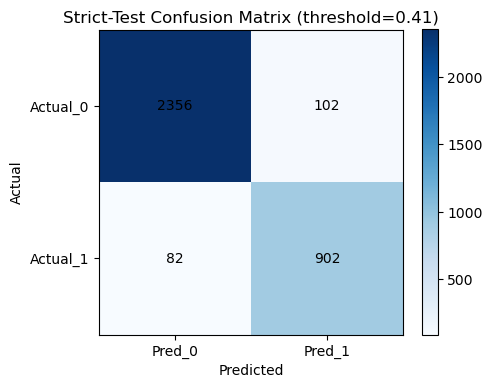

Strict-test Brier score (lower is better): 0.040355


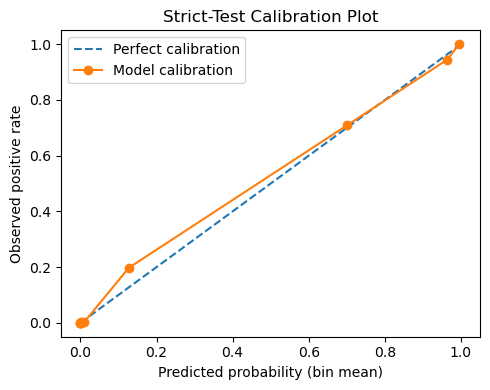

Strict-test ROC-AUC: 0.987515


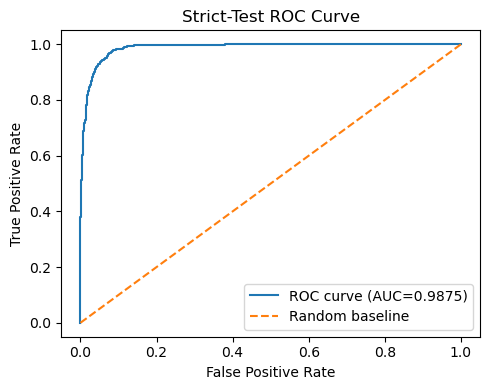

Saved artifacts:
- /Users/Aqsa/Desktop/FinTrackAI/server/ml/models/archive (5)/artifacts_goal_report/strict_test_confusion_matrix.png
- /Users/Aqsa/Desktop/FinTrackAI/server/ml/models/archive (5)/artifacts_goal_report/strict_test_calibration_plot.png
- /Users/Aqsa/Desktop/FinTrackAI/server/ml/models/archive (5)/artifacts_goal_report/strict_test_roc_curve.png


In [17]:
print('SECTION 15: Strict-Test Reporting Artifacts')

# Why: generate report-ready visual artifacts for final model behavior on strict holdout.
# Outputs:
# 1) Confusion matrix at FINAL_THRESHOLD
# 2) Calibration plot (reliability curve) + Brier score
# 3) Saved PNG files for documentation

from pathlib import Path
from sklearn.metrics import confusion_matrix, roc_curve
from sklearn.calibration import calibration_curve

needed = ['best_cls_model', 'Xs_te', 'ys_te_cls']
missing = [x for x in needed if x not in globals()]
if missing:
    raise RuntimeError(f'Missing required objects: {missing}. Run Sections 12 and 14 first.')

th = FINAL_THRESHOLD if 'FINAL_THRESHOLD' in globals() else 0.50
proba_strict = best_cls_model.predict_proba(Xs_te)[:,1]
pred_strict = (proba_strict >= th).astype(int)

report_dir = Path('artifacts_goal_report')
report_dir.mkdir(exist_ok=True)

# ---------------------
# Confusion Matrix Plot
# ---------------------
cm = confusion_matrix(ys_te_cls, pred_strict)
cm_df = pd.DataFrame(cm, index=['Actual_0','Actual_1'], columns=['Pred_0','Pred_1'])
print('Strict-test confusion matrix at threshold:', th)
display(cm_df)

fig1 = plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks([0,1], ['Pred_0','Pred_1'])
plt.yticks([0,1], ['Actual_0','Actual_1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Strict-Test Confusion Matrix (threshold={th:.2f})')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.tight_layout()
cm_path = report_dir / 'strict_test_confusion_matrix.png'
fig1.savefig(cm_path, dpi=160)
plt.show()

# -----------------
# Calibration Plot
# -----------------
prob_true, prob_pred = calibration_curve(ys_te_cls, proba_strict, n_bins=10, strategy='quantile')

# Brier score for calibration quality (lower is better)
brier = float(np.mean((proba_strict - ys_te_cls.values) ** 2))
print('Strict-test Brier score (lower is better):', round(brier, 6))

fig2 = plt.figure(figsize=(5,4))
plt.plot([0,1], [0,1], '--', label='Perfect calibration')
plt.plot(prob_pred, prob_true, marker='o', label='Model calibration')
plt.xlabel('Predicted probability (bin mean)')
plt.ylabel('Observed positive rate')
plt.title('Strict-Test Calibration Plot')
plt.legend()
plt.tight_layout()
cal_path = report_dir / 'strict_test_calibration_plot.png'
fig2.savefig(cal_path, dpi=160)
plt.show()


# -------------
# ROC Curve Plot
# -------------
fpr, tpr, _ = roc_curve(ys_te_cls, proba_strict)
roc_auc_val = roc_auc_score(ys_te_cls, proba_strict)
print('Strict-test ROC-AUC:', round(float(roc_auc_val), 6))

fig3 = plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f'ROC curve (AUC={roc_auc_val:.4f})')
plt.plot([0,1], [0,1], '--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Strict-Test ROC Curve')
plt.legend()
plt.tight_layout()
roc_path = report_dir / 'strict_test_roc_curve.png'
fig3.savefig(roc_path, dpi=160)
plt.show()

print('Saved artifacts:')
print('-', cm_path.resolve())
print('-', cal_path.resolve())
print('-', roc_path.resolve())


## 16) Permutation Leakage Sanity Test (Shuffled Target)
Train models on shuffled training targets and evaluate on real test labels.


In [18]:
print('SECTION 16: Permutation Leakage Sanity Test')
# Why: if model still performs very well on shuffled target labels, leakage is likely.
# Expected behavior (healthy pipeline):
# - Regression R2 should drop near 0 (or negative)
# - Classification AUC should drop near 0.5 and F1 near weak baseline
needed = ['X_train','X_test','y_train_reg','y_test_reg','y_train_cls','y_test_cls']
missing = [x for x in needed if x not in globals()]
if missing:
    raise RuntimeError(f'Missing required objects: {missing}. Run Sections 4-6 first.')
rng = np.random.default_rng(SEED)
# ----------------------
# Regression permutation
# ----------------------
y_reg_shuf = pd.Series(rng.permutation(y_train_reg.values), index=y_train_reg.index)
# Use same family as production winner when available; fallback to RF.
if 'FINAL_REG_MODEL_NAME' in globals() and FINAL_REG_MODEL_NAME == 'LightGBMRegressor' and 'HAS_LIGHTGBM' in globals() and HAS_LIGHTGBM:
    reg_perm = LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31, subsample=0.8, colsample_bytree=0.8, random_state=SEED)
elif 'FINAL_REG_MODEL_NAME' in globals() and FINAL_REG_MODEL_NAME == 'XGBoostRegressor' and 'HAS_XGBOOST' in globals() and HAS_XGBOOST:
    reg_perm = XGBRegressor(n_estimators=250, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, objective='reg:squarederror', random_state=SEED, n_jobs=1)
else:
    reg_perm = RandomForestRegressor(n_estimators=180, max_depth=12, min_samples_split=20, min_samples_leaf=10, max_features='sqrt', random_state=SEED, n_jobs=1)
reg_perm.fit(X_train, y_reg_shuf)
reg_pred = reg_perm.predict(X_test)
reg_metrics = {
    'MAE': mean_absolute_error(y_test_reg, reg_pred),
    'RMSE': mean_squared_error(y_test_reg, reg_pred, squared=False),
    'R2': r2_score(y_test_reg, reg_pred)
}
print('Regression metrics with shuffled target (expect weak):', reg_metrics)
# -------------------------
# Classification permutation
# -------------------------
y_cls_shuf = pd.Series(rng.permutation(y_train_cls.values), index=y_train_cls.index)
if 'FINAL_CLS_MODEL_NAME' in globals() and FINAL_CLS_MODEL_NAME == 'LightGBMClassifier' and 'HAS_LIGHTGBM' in globals() and HAS_LIGHTGBM:
    cls_perm = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, subsample=0.8, colsample_bytree=0.8, random_state=SEED)
elif 'FINAL_CLS_MODEL_NAME' in globals() and FINAL_CLS_MODEL_NAME == 'XGBoostClassifier' and 'HAS_XGBOOST' in globals() and HAS_XGBOOST:
    cls_perm = XGBClassifier(n_estimators=250, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=SEED, n_jobs=1)
else:
    cls_perm = RandomForestClassifier(n_estimators=180, max_depth=10, min_samples_split=20, min_samples_leaf=8, max_features='sqrt', random_state=SEED, n_jobs=1, class_weight='balanced_subsample')
cls_perm.fit(X_train, y_cls_shuf)
cls_prob = cls_perm.predict_proba(X_test)[:,1]
th = FINAL_THRESHOLD if 'FINAL_THRESHOLD' in globals() else 0.5
cls_pred = (cls_prob >= th).astype(int)
cls_metrics = {
    'Accuracy': accuracy_score(y_test_cls, cls_pred),
    'Precision': precision_score(y_test_cls, cls_pred, zero_division=0),
    'Recall': recall_score(y_test_cls, cls_pred, zero_division=0),
    'F1': f1_score(y_test_cls, cls_pred, zero_division=0),
    'AUC': roc_auc_score(y_test_cls, cls_prob),
    'PR_AUC': average_precision_score(y_test_cls, cls_prob)
}
print('Classification metrics with shuffled target (expect weak):', cls_metrics)
print('Interpretation guide: strong performance after shuffling is a leakage warning; weak/near-random performance supports pipeline integrity.')


SECTION 16: Permutation Leakage Sanity Test
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000777 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3311
[LightGBM] [Info] Number of data points in the train set: 20126, number of used features: 16
[LightGBM] [Info] Start training from score -9877.451171
Regression metrics with shuffled target (expect weak): {'MAE': 21707.020768943534, 'RMSE': 31453.954966334997, 'R2': -0.06449252367054314}
[LightGBM] [Info] Number of positive: 5615, number of negative: 14511
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000407 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3311
[LightGBM] [Info] Number of data points in the train set: 20126, number of us

In [19]:
from pathlib import Path
import joblib

out = Path("/Users/Aqsa/Desktop/FinTrackAI/server/ml/models/archive (5)/artifacts_goal")
out.mkdir(parents=True, exist_ok=True)

joblib.dump(best_reg_model, out / "goal_regression_lightgbm.joblib")
joblib.dump(best_cls_model, out / "goal_classification_lightgbm.pkl")
joblib.dump(feature_cols, out / "goal_feature_cols.joblib")

print("Saved LightGBM artifacts to:", out)


Saved LightGBM artifacts to: /Users/Aqsa/Desktop/FinTrackAI/server/ml/models/archive (5)/artifacts_goal
